# Task 1: Data Exploration with Pandas

In [1]:
import pandas as pd
df =  pd.read_csv("students.csv")
df.head()

,name,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
0,Alice,88,92,76,80,95,92,4.5,1
1,Bob,42,55,48,50,60,65,1.2,0
2,Charlie,75,70,80,68,88,85,3.0,1
3,Diana,95,98,91,89,97,98,6.0,1
4,Eve,38,42,50,45,55,58,0.8,0


In [2]:
print("Shape: ", df.shape)
print("Data Types: ", df.dtypes)
print("Summary: ", df.describe())
print("Pass/Fail Counts: ", df['passed'].value_counts())

Shape:  (15, 9)
Data Types:  name                       str
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object
Summary:              math    science    english    history         pe  attendance_pct  \
count  15.000000  15.000000  15.000000  15.000000  15.000000       15.000000   
mean   65.000000  66.733333  66.200000  63.400000  74.800000       75.800000   
std    20.060622  18.967893  17.773174  16.936014  16.657045       14.722189   
min    30.000000  35.000000  40.000000  28.000000  45.000000       50.000000   
25%    51.500000  53.500000  49.000000  53.500000  61.000000       63.500000   
50%    65.000000  65.000000  70.000000  62.000000  75.000000       78.000000   
75%    80.000000  77.000000  81.000000  73.500000  89.000000       86.500000   
max    95.000000  98.000000 

In [3]:
subjects=['math','science','english','history','pe']
pass_avg=df[df['passed']==1][subjects].mean()
fail_avg=df[df['passed']==0][subjects].mean()
print("Pass: ", pass_avg)
print("Fail: ", fail_avg)

Pass:  math       78.222222
science    78.555556
english    79.111111
history    73.444444
pe         86.000000
dtype: float64
Fail:  math       45.166667
science    49.000000
english    46.833333
history    48.333333
pe         58.000000
dtype: float64


In [4]:
df["overall_avg"]=df[subjects].mean(axis=1)
top=df.loc[df["overall_avg"].idxmax()]
print(top['name'], top['overall_avg'])

Diana 94.0


# Task 2: Data Visualization with Matplotlib

In [5]:
import matplotlib.pyplot as plt

In [6]:
df['avg_score'] = df[subjects].mean(axis=1)

# 1. BAR CHART

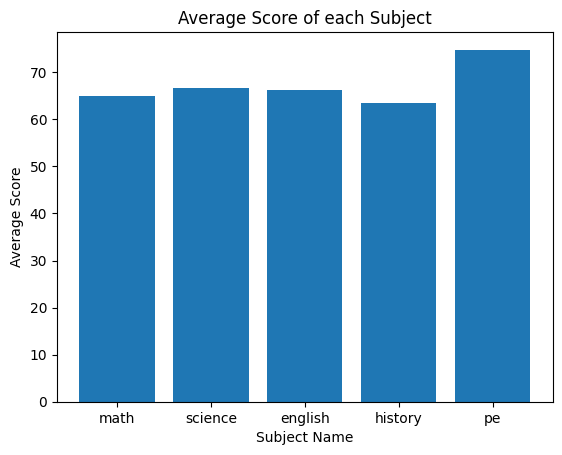

In [7]:
plt.figure()
plt.bar(subjects,df[subjects].mean())
plt.title("Average Score of each Subject")
plt.xlabel("Subject Name")
plt.ylabel("Average Score")
plt.savefig('plot1_bar.png')
plt.show()

# 2. HISTOGRAM

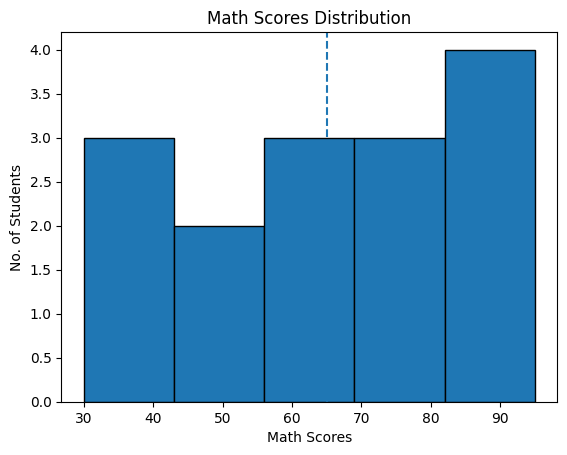

In [8]:
plt.figure()
plt.hist(df['math'], bins=5, edgecolor='black')
plt.axvline(df['math'].mean(), linestyle='dashed')
plt.title("Math Scores Distribution")
plt.xlabel("Math Scores")
plt.ylabel("No. of Students")
plt.savefig("plot2_hist.png")
plt.show()

# SCATTER PLOT

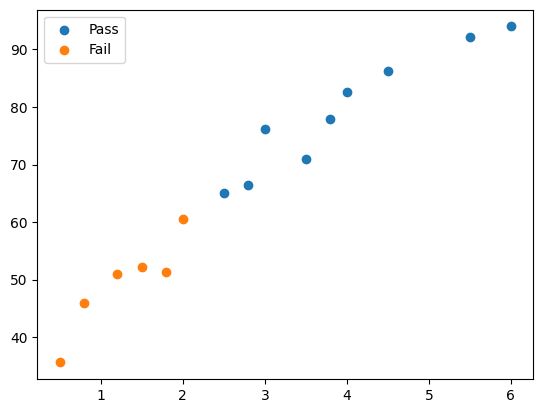

In [9]:
plt.figure()
p=df[df['passed']==1]
f=df[df['passed']==0]
plt.scatter(p['study_hours_per_day'],p['avg_score'],label='Pass')
plt.scatter(f['study_hours_per_day'],f['avg_score'],label='Fail')
plt.legend()
plt.savefig('plot3_scatter.png')
plt.show()

# 4. BOX PLOT

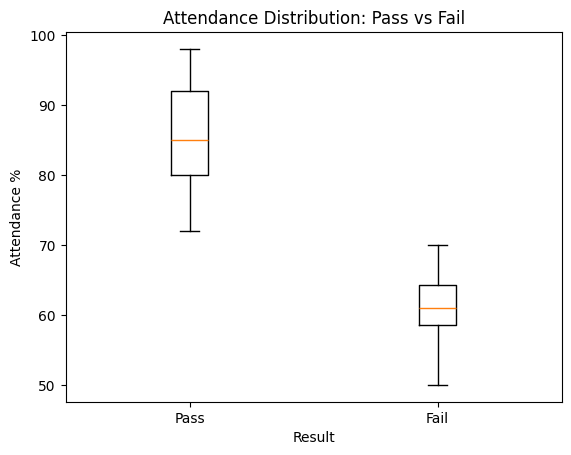

In [18]:
plt.figure()
plt.boxplot([
    df[df['passed']==1]['attendance_pct'],
    df[df['passed']==0]['attendance_pct']], 
    tick_labels=['Pass','Fail'])
plt.title("Attendance Distribution: Pass vs Fail")
plt.xlabel("Result")
plt.ylabel("Attendance %")
plt.savefig('plot4_box.png')
plt.show()

# LINE PLOT

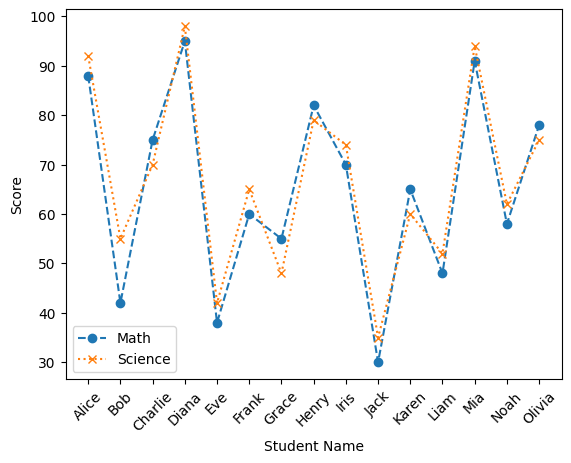

In [19]:
plt.figure()
plt.plot(df['name'],df['math'], marker='o', label='Math',linestyle='dashed')
plt.plot(df['name'],df['science'], marker='x', label='Science',linestyle='dotted')
plt.xticks(rotation=45)
plt.xlabel("Student Name")
plt.ylabel("Score")
plt.legend()
plt.savefig('plot5_line.png')
plt.show()

# TASK 3: Data Visualization with Seaborn

In [20]:
import seaborn as sns

# 6. SEABORN BAR PLOT

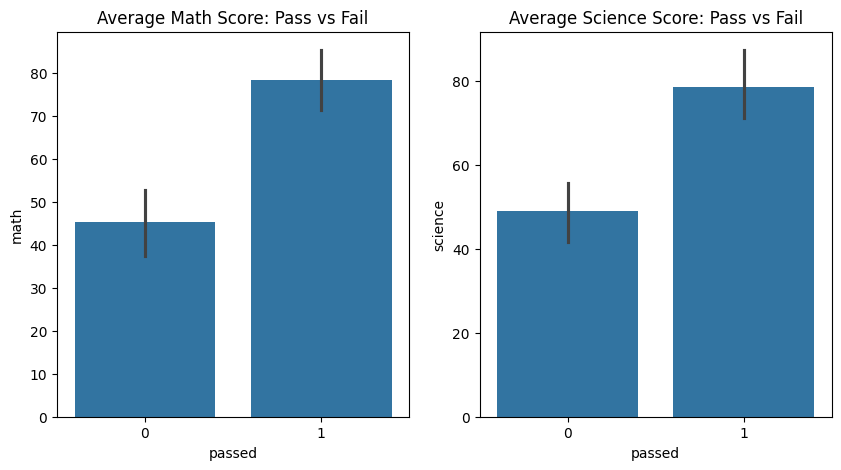

In [24]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sns.barplot(data=df,x='passed',y='math')
plt.title("Average Math Score: Pass vs Fail")
plt.subplot(1,2,2)
sns.barplot(data=df,x='passed',y='science')
plt.title("Average Science Score: Pass vs Fail")
plt.savefig('plot6_seaborn_bar.png')
plt.show()

# 2. SEABORN SCATTER PLOT

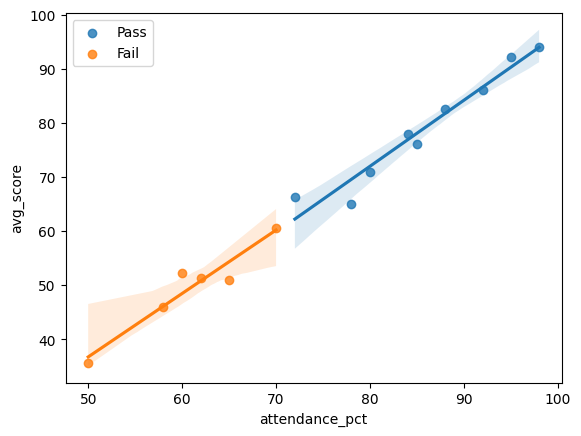

In [25]:
plt.figure()
sns.regplot(data=df[df['passed']==1],x='attendance_pct',y='avg_score',label='Pass')
sns.regplot(data=df[df['passed']==0],x='attendance_pct',y='avg_score',label='Fail')
plt.legend()
plt.savefig('plot7_seaborn_scatter.png')
plt.show()

In [27]:
#  COMMENT
#Seaborn was easier to use for built-in visuals, styling and designing
# While Matplotlib required more manual customisation

# TASK 4: Machine Learning

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Step 1: Prepare Data

In [32]:
X=df[['math','science','english','history','pe','attendance_pct','study_hours_per_day']]
y=df['passed']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2, random_state=42)
scaler= StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.fit_transform(X_test)

# Step 2: Train a Model

In [33]:
model = LogisticRegression()
model.fit(X_train_scaled,y_train)
print("Training Accuracy: ", model.score(X_train_scaled,y_train))

Training Accuracy:  1.0


# Step 3: Evaluate the Model

In [34]:
p=model.predict(X_test_scaled)
print("Test Accuracy: ", model.score(X_test_scaled,y_test))
names=df.loc[X_test.index,'name']
for i in range(len(p)):
    print(names.iloc[i],y_test.iloc[i],p[i])

Test Accuracy:  0.6666666666666666
Jack 0 0
Liam 0 1
Alice 1 1


# Step 4: Feature Importance

In [36]:
cf=model.coef_[0]
features=X.columns
pairs=sorted(zip(features,cf), key=lambda x: abs(x[1]),reverse=True)
for f,c in pairs:
    print(f,c)

english 0.8125127982724647
attendance_pct 0.521876340433209
study_hours_per_day 0.4844326627100155
pe 0.47497406284967786
math 0.4379439308687359
science 0.3230097624690249
history 0.26292892629062437


# Horizontal Bar Chart (Step 4 Contd.)

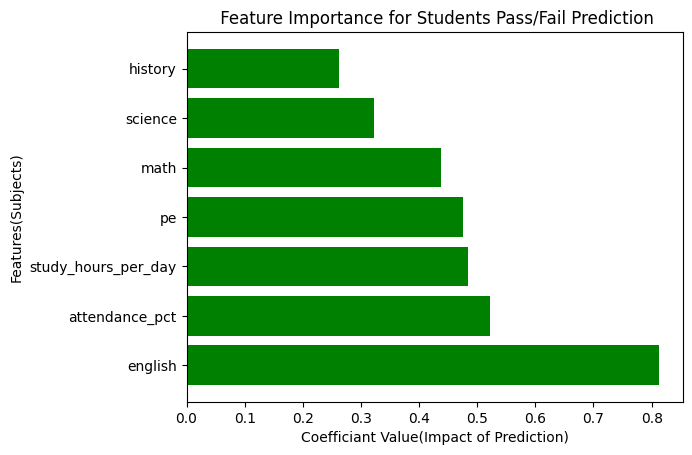

In [39]:
plt.figure()
value=[c for f,c in pairs]
labels=[f for f,c in pairs]
colors=["green" if v>0 else "red" for v in value]
plt.barh(labels,value,color=colors)
plt.title(" Feature Importance for Students Pass/Fail Prediction")
plt.xlabel("Coefficiant Value(Impact of Prediction)")
plt.ylabel("Features(Subjects)")
plt.show()

# Step 5: Predict for New Student (Bonus - 2 Marks)

In [43]:
new_st=pd.DataFrame([[87,71,60,56,89,77,9.8]], columns=X.columns)
scaled=scaler.transform(new_st)
p=model.predict(scaled)
print("Prediction: ",'Pass' if p[0]==1 else 'Fail')
print("Probability: ", model.predict_proba(scaled))

Prediction:  Pass
Probability:  [[0.00279854 0.99720146]]
